# 10 — Particle snapshot construction

## Purpose

This notebook constructs mathematically consistent particle-level snapshots from the
validated pilot MercuryDPM trajectory.

The notebook does **not** perform POD. Its objectives are to:

1. load the previously validated snapshot index;
2. extract the stationary snapshots with \(t \geq 1377\);
3. verify particle count, ordering, radii and species throughout that interval;
4. construct fixed-dimensional XYZ and XZ position matrices;
5. document the representation used by the later particle-level POD.

## Particle representation

For snapshot \(j\), the full translational particle state is

\[
\mathbf{x}_j =
(x_{1,j},y_{1,j},z_{1,j},\ldots,x_{N_p,j},y_{N_p,j},z_{N_p,j})^\mathsf{T}
\in \mathbb{R}^{3N_p}.
\]

Two representations will be retained:

- **XYZ positions:** the primary physically complete particle representation;
- **XZ positions:** a diagnostic representation matched to the XZ continuum fields.

Particle radii and species labels are treated as fixed particle attributes rather than
POD variables. Velocities and rotational quantities are not included in the primary
representation because the concentration fields used in the Route A comparison depend
on particle locations, radii and species, not on variables with different physical units.

The particle rows do not contain explicit IDs. Notebook 09 supplied strong evidence that
row ordering is stable within this trajectory, but this does not imply correspondence
between different simulations.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd


def locate_project_root(start: Path) -> Path:
    """Locate the repository whether Jupyter starts in the root or notebooks/."""
    start = start.resolve()

    for candidate in (start, *start.parents):
        if (
            (candidate / "notebooks").is_dir()
            and (candidate / "data").is_dir()
            and (candidate / "results").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the msc-rom-particle-systems project root."
    )


PROJECT_ROOT = locate_project_root(Path.cwd())

PILOT_DIRECTORY = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "particle_dem"
    / "pilot_size_ratio_1_000000_num_1"
)

PARTICLE_DATA_PATH = (
    PILOT_DIRECTORY
    / "rotating_drum_bidisperse_size_ratio_1_000000_num_1.data"
)

SNAPSHOT_INDEX_PATH = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "particle_snapshot_index_ratio_1_000000_num_1.csv"
)

VALIDATION_PATH = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "particle_snapshot_validation_ratio_1_000000_num_1.json"
)

required_paths = [
    PARTICLE_DATA_PATH,
    SNAPSHOT_INDEX_PATH,
    VALIDATION_PATH,
]

for path in required_paths:
    if not path.exists():
        raise FileNotFoundError(path)

snapshot_index = pd.read_csv(SNAPSHOT_INDEX_PATH)

with VALIDATION_PATH.open("r") as handle:
    validation_summary = json.load(handle)

STATIONARY_TIME_MIN = float(
    validation_summary["stationary_threshold"]
)

stationary_index = (
    snapshot_index.loc[
        snapshot_index["time"] >= STATIONARY_TIME_MIN
    ]
    .copy()
    .reset_index(drop=True)
)

print("Project root:", PROJECT_ROOT)
print("Particle file:", PARTICLE_DATA_PATH.name)
print(
    "Particle file size:",
    f"{PARTICLE_DATA_PATH.stat().st_size / 1024**3:.3f} GiB",
)
print("Total indexed snapshots:", len(snapshot_index))
print("Stationary threshold:", STATIONARY_TIME_MIN)
print("Stationary snapshots:", len(stationary_index))
print(
    "Stationary time range:",
    stationary_index["time"].iloc[0],
    "to",
    stationary_index["time"].iloc[-1],
)

assert len(snapshot_index) == validation_summary["snapshot_count"]
assert len(stationary_index) == validation_summary["stationary_snapshot_count"]
assert stationary_index["time"].is_monotonic_increasing

Project root: /Users/rallen/Documents/msc-rom-particle-systems
Particle file: rotating_drum_bidisperse_size_ratio_1_000000_num_1.data
Particle file size: 1.934 GiB
Total indexed snapshots: 1002
Stationary threshold: 1377.0
Stationary snapshots: 201
Stationary time range: 1378.133363 to 1720.721256


In [2]:
PARTICLE_COLUMNS = [
    "x",
    "y",
    "z",
    "vx",
    "vy",
    "vz",
    "radius",
    "rotation_1",   # precise MercuryDPM interpretation not yet assumed
    "rotation_2",
    "rotation_3",
    "omega_x",
    "omega_y",
    "omega_z",
    "species_index",
]


def read_particle_snapshot(
    path: Path,
    byte_offset: int,
) -> tuple[dict, np.ndarray]:
    """Read one snapshot without loading the complete multi-gigabyte file."""
    with path.open("rb") as handle:
        handle.seek(int(byte_offset))

        header = handle.readline().split()

        if len(header) != 8:
            raise ValueError(
                f"Snapshot header has {len(header)} values; expected 8."
            )

        particle_count = int(header[0])
        snapshot_time = float(header[1])
        domain_bounds = np.asarray(header[2:8], dtype=np.float64)

        values = np.empty(
            (particle_count, len(PARTICLE_COLUMNS)),
            dtype=np.float64,
        )

        for particle_row in range(particle_count):
            row = np.fromstring(
                handle.readline(),
                sep=" ",
                dtype=np.float64,
            )

            if row.size != len(PARTICLE_COLUMNS):
                raise ValueError(
                    f"Particle row {particle_row} contains "
                    f"{row.size} values; expected "
                    f"{len(PARTICLE_COLUMNS)}."
                )

            values[particle_row] = row

    metadata = {
        "particle_count": particle_count,
        "time": snapshot_time,
        "domain_bounds": domain_bounds,
    }

    return metadata, values


first_row = stationary_index.iloc[0]
last_row = stationary_index.iloc[-1]

first_metadata, first_values = read_particle_snapshot(
    PARTICLE_DATA_PATH,
    first_row["byte_offset"],
)

last_metadata, last_values = read_particle_snapshot(
    PARTICLE_DATA_PATH,
    last_row["byte_offset"],
)

endpoint_checks = pd.DataFrame(
    [
        {
            "snapshot": "first stationary",
            "indexed_time": first_row["time"],
            "read_time": first_metadata["time"],
            "particle_count": first_metadata["particle_count"],
            "all_values_finite": np.isfinite(first_values).all(),
        },
        {
            "snapshot": "final",
            "indexed_time": last_row["time"],
            "read_time": last_metadata["time"],
            "particle_count": last_metadata["particle_count"],
            "all_values_finite": np.isfinite(last_values).all(),
        },
    ]
)

display(endpoint_checks)

print(
    "Endpoint radius sequences identical:",
    np.array_equal(first_values[:, 6], last_values[:, 6]),
)

print(
    "Endpoint species sequences identical:",
    np.array_equal(
        first_values[:, 13].astype(np.int64),
        last_values[:, 13].astype(np.int64),
    ),
)

assert np.isclose(first_metadata["time"], first_row["time"])
assert np.isclose(last_metadata["time"], last_row["time"])
assert first_metadata["particle_count"] == validation_summary["particle_count"]
assert last_metadata["particle_count"] == validation_summary["particle_count"]

,snapshot,indexed_time,read_time,particle_count,all_values_finite
0,first stationary,1378.133363,1378.133363,10792,True
1,final,1720.721256,1720.721256,10792,True


Endpoint radius sequences identical: True
Endpoint species sequences identical: True


In [3]:
number_of_snapshots = len(stationary_index)
number_of_particles = int(validation_summary["particle_count"])

positions_xyz = np.empty(
    (number_of_snapshots, number_of_particles, 3),
    dtype=np.float64,
)

snapshot_times = np.empty(
    number_of_snapshots,
    dtype=np.float64,
)

reference_radii = None
reference_species = None

for snapshot_number, row in stationary_index.iterrows():
    metadata, values = read_particle_snapshot(
        PARTICLE_DATA_PATH,
        row["byte_offset"],
    )

    if metadata["particle_count"] != number_of_particles:
        raise ValueError(
            f"Snapshot {snapshot_number} has "
            f"{metadata['particle_count']} particles; "
            f"expected {number_of_particles}."
        )

    if not np.isclose(metadata["time"], row["time"], rtol=0, atol=1e-8):
        raise ValueError(
            f"Timestamp mismatch at snapshot {snapshot_number}."
        )

    if not np.isfinite(values).all():
        raise ValueError(
            f"Non-finite particle value at snapshot {snapshot_number}."
        )

    radii = values[:, 6]
    species = values[:, 13].astype(np.int64)

    if snapshot_number == 0:
        reference_radii = radii.copy()
        reference_species = species.copy()
    else:
        if not np.array_equal(radii, reference_radii):
            raise ValueError(
                f"Radius ordering changed at snapshot {snapshot_number}."
            )

        if not np.array_equal(species, reference_species):
            raise ValueError(
                f"Species ordering changed at snapshot {snapshot_number}."
            )

    positions_xyz[snapshot_number] = values[:, 0:3]
    snapshot_times[snapshot_number] = metadata["time"]

    if (
        (snapshot_number + 1) % 50 == 0
        or snapshot_number + 1 == number_of_snapshots
    ):
        print(
            f"Loaded {snapshot_number + 1}"
            f"/{number_of_snapshots} stationary snapshots"
        )


# Tensor forms: snapshot × particle × spatial coordinate
positions_xz = positions_xyz[:, :, [0, 2]]

# POD matrix convention: feature × snapshot
X_xyz = positions_xyz.reshape(number_of_snapshots, -1).T
X_xz = positions_xz.reshape(number_of_snapshots, -1).T

print("\nXYZ tensor shape:", positions_xyz.shape)
print("XZ tensor shape:", positions_xz.shape)
print("XYZ POD matrix shape:", X_xyz.shape)
print("XZ POD matrix shape:", X_xz.shape)

print(
    "\nXYZ matrix memory:",
    f"{X_xyz.nbytes / 1024**2:.2f} MiB",
)
print(
    "XZ matrix memory:",
    f"{X_xz.nbytes / 1024**2:.2f} MiB",
)

print("\nAll XYZ values finite:", np.isfinite(X_xyz).all())
print("All XZ values finite:", np.isfinite(X_xz).all())
print("Times strictly increasing:", np.all(np.diff(snapshot_times) > 0))
print("Unique particles:", number_of_particles)
print("Species counts:")
display(
    pd.Series(reference_species)
    .value_counts()
    .sort_index()
    .rename_axis("species_index")
    .reset_index(name="particle_count")
)

assert X_xyz.shape == (
    3 * number_of_particles,
    number_of_snapshots,
)

assert X_xz.shape == (
    2 * number_of_particles,
    number_of_snapshots,
)

assert np.isfinite(X_xyz).all()
assert np.all(np.diff(snapshot_times) > 0)

Loaded 50/201 stationary snapshots
Loaded 100/201 stationary snapshots
Loaded 150/201 stationary snapshots
Loaded 200/201 stationary snapshots
Loaded 201/201 stationary snapshots

XYZ tensor shape: (201, 10792, 3)
XZ tensor shape: (201, 10792, 2)
XYZ POD matrix shape: (32376, 201)
XZ POD matrix shape: (21584, 201)

XYZ matrix memory: 49.65 MiB
XZ matrix memory: 33.10 MiB

All XYZ values finite: True
All XZ values finite: True
Times strictly increasing: True
Unique particles: 10792
Species counts:


,species_index,particle_count
0,0,5396
1,1,5396


## Affine centring and scale diagnostics

POD will be applied to deviations from the temporal mean particle configuration.

For the XYZ representation,

$$
X_{\mathrm{c}}
=
X-\overline{\mathbf{x}}\mathbf{1}^{\mathsf{T}},
\qquad
\overline{\mathbf{x}}
=
\frac{1}{N_s}
\sum_{j=1}^{N_s}\mathbf{x}_j.
$$

The mean is calculated separately for every particle coordinate. Reconstruction
will therefore use the affine form

$$
\widehat{\mathbf{x}}_j^{(r)}
=
\overline{\mathbf{x}}
+
U_r U_r^{\mathsf{T}}
\left(
\mathbf{x}_j-\overline{\mathbf{x}}
\right).
$$

We do not remove the centre of mass or apply a separate translation or rotation
to each snapshot. Those operations could remove physically meaningful motion
and would alter the subsequent coarse-grained fields.

All position coordinates have the same units, so no axis-dependent
standardisation is applied. XYZ is retained as the physically complete
representation, while XZ will be examined as a diagnostic representation
aligned with the continuum output.

# Mean particle configuration: particle × coordinate
mean_positions_xyz = positions_xyz.mean(axis=0)

# Deviations from the temporal mean configuration
deviations_xyz = (
    positions_xyz
    - mean_positions_xyz[np.newaxis, :, :]
)

deviations_xz = deviations_xyz[:, :, [0, 2]]

# POD convention: feature × snapshot
X_xyz_centered = deviations_xyz.reshape(
    number_of_snapshots, -1
).T

X_xz_centered = deviations_xz.reshape(
    number_of_snapshots, -1
).T

# Squared Euclidean fluctuation by coordinate.
# This is POD variance, not mechanical energy.
axis_squared_fluctuation = np.sum(
    deviations_xyz**2,
    axis=(0, 1),
)

axis_fraction = (
    axis_squared_fluctuation
    / axis_squared_fluctuation.sum()
)

axis_diagnostics = pd.DataFrame(
    {
        "coordinate": ["x", "y", "z"],
        "squared_fluctuation": axis_squared_fluctuation,
        "fraction_of_XYZ_fluctuation": axis_fraction,
    }
)

display(axis_diagnostics)

print(
    "Maximum absolute centred XYZ feature mean:",
    np.max(
        np.abs(
            X_xyz_centered.mean(axis=1)
        )
    ),
)

print(
    "Maximum absolute centred XZ feature mean:",
    np.max(
        np.abs(
            X_xz_centered.mean(axis=1)
        )
    ),
)

print(
    "\nFraction retained by XZ:",
    float(axis_fraction[0] + axis_fraction[2]),
)

print(
    "Fraction contributed by y:",
    float(axis_fraction[1]),
)

print(
    "\nTotal centred XYZ squared fluctuation:",
    float(np.sum(X_xyz_centered**2)),
)

print(
    "Total centred XZ squared fluctuation:",
    float(np.sum(X_xz_centered**2)),
)

assert np.allclose(
    X_xyz_centered.mean(axis=1),
    0.0,
    atol=1e-12,
)

assert np.allclose(
    X_xz_centered.mean(axis=1),
    0.0,
    atol=1e-12,
)

In [6]:
# RMS distance of each labelled particle from its own temporal mean position
particle_rms_displacement = np.sqrt(
    np.mean(
        np.sum(deviations_xyz**2, axis=2),
        axis=0,
    )
)

# Net labelled-particle displacement between the first and final snapshots
particle_endpoint_displacement = np.linalg.norm(
    positions_xyz[-1] - positions_xyz[0],
    axis=1,
)

# Displacement and displacement-rate between saved snapshots
successive_displacement = np.linalg.norm(
    np.diff(positions_xyz, axis=0),
    axis=2,
)

saved_time_steps = np.diff(snapshot_times)

successive_displacement_rate = (
    successive_displacement
    / saved_time_steps[:, np.newaxis]
)

particle_motion = pd.DataFrame(
    {
        "species_index": reference_species,
        "rms_displacement_from_temporal_mean":
            particle_rms_displacement,
        "first_to_final_displacement":
            particle_endpoint_displacement,
    }
)

species_motion_summary = (
    particle_motion
    .groupby("species_index")
    .agg(
        particle_count=(
            "rms_displacement_from_temporal_mean",
            "size",
        ),
        mean_rms_displacement=(
            "rms_displacement_from_temporal_mean",
            "mean",
        ),
        median_rms_displacement=(
            "rms_displacement_from_temporal_mean",
            "median",
        ),
        maximum_rms_displacement=(
            "rms_displacement_from_temporal_mean",
            "max",
        ),
        mean_endpoint_displacement=(
            "first_to_final_displacement",
            "mean",
        ),
        median_endpoint_displacement=(
            "first_to_final_displacement",
            "median",
        ),
        maximum_endpoint_displacement=(
            "first_to_final_displacement",
            "max",
        ),
    )
    .reset_index()
)

display(species_motion_summary)

successive_summary = pd.DataFrame(
    {
        "quantity": [
            "saved-snapshot displacement",
            "saved-snapshot displacement rate",
        ],
        "mean": [
            successive_displacement.mean(),
            successive_displacement_rate.mean(),
        ],
        "median": [
            np.median(successive_displacement),
            np.median(successive_displacement_rate),
        ],
        "95th_percentile": [
            np.quantile(successive_displacement, 0.95),
            np.quantile(successive_displacement_rate, 0.95),
        ],
        "maximum": [
            successive_displacement.max(),
            successive_displacement_rate.max(),
        ],
    }
)

print("Successive-snapshot motion:")
display(successive_summary)

print(
    "Saved-time-step range:",
    float(saved_time_steps.min()),
    "to",
    float(saved_time_steps.max()),
)

,species_index,particle_count,mean_rms_displacement,median_rms_displacement,maximum_rms_displacement,mean_endpoint_displacement,median_endpoint_displacement,maximum_endpoint_displacement
0,0,5396,15.710711,16.686228,22.878940,20.531205,17.919242,54.492454
1,1,5396,15.189479,16.024063,23.084621,19.800903,17.039414,53.693750


Successive-snapshot motion:


,quantity,mean,median,95th_percentile,maximum
0,saved-snapshot displacement,1.938313,1.556309,5.797146,12.411829
1,saved-snapshot displacement rate,1.131716,0.906017,3.378708,7.214015


Saved-time-step range: 0.2051969999999983 to 1.7205170000002


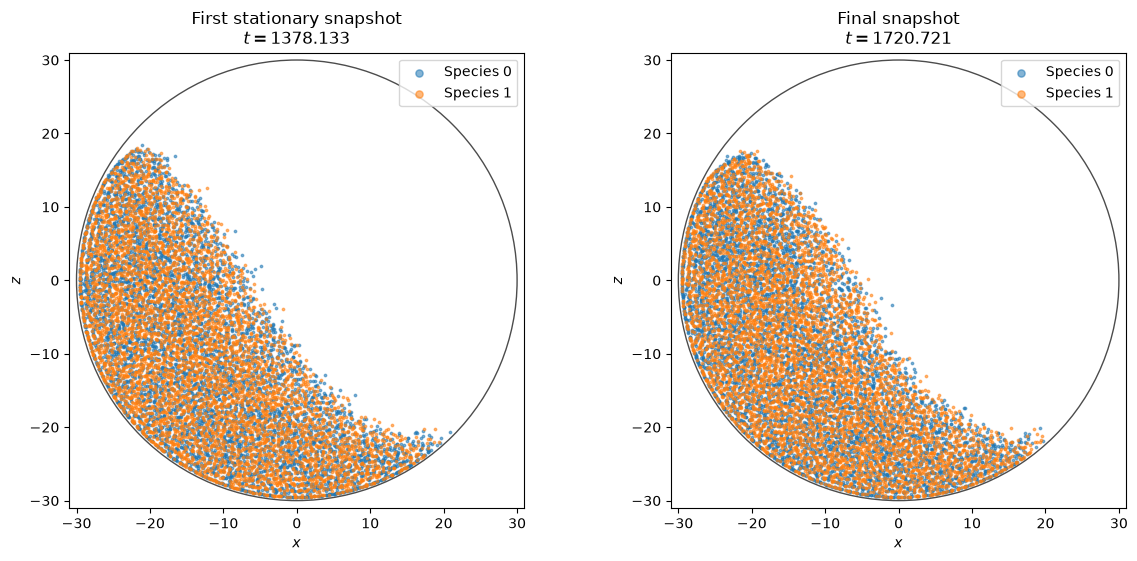

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle


species_colours = {
    0: "tab:blue",
    1: "tab:orange",
}

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5.5),
    constrained_layout=True,
)

plot_cases = [
    (
        axes[0],
        positions_xyz[0],
        snapshot_times[0],
        "First stationary snapshot",
    ),
    (
        axes[1],
        positions_xyz[-1],
        snapshot_times[-1],
        "Final snapshot",
    ),
]

for axis, positions, time, title in plot_cases:
    for species_index in np.unique(reference_species):
        mask = reference_species == species_index

        axis.scatter(
            positions[mask, 0],
            positions[mask, 2],
            s=3,
            alpha=0.55,
            color=species_colours[int(species_index)],
            label=f"Species {species_index}",
            rasterized=True,
        )

    # Domain bounds suggest a drum radius of 30, but this circle is
    # included only as a visual guide rather than a newly inferred wall model.
    axis.add_patch(
        Circle(
            (0, 0),
            radius=30,
            fill=False,
            color="black",
            linewidth=1.0,
            alpha=0.7,
        )
    )

    axis.set(
        title=f"{title}\n$t={time:.3f}$",
        xlabel="$x$",
        ylabel="$z$",
        xlim=(-31, 31),
        ylim=(-31, 31),
        aspect="equal",
    )

    axis.legend(
        loc="upper right",
        markerscale=3,
        frameon=True,
    )

plt.show()

## Interpretation of the representation diagnostics

### Results obtained

- The XZ coordinates contain approximately \(99.60\%\) of the total centred
  particle-position fluctuation.
- The thin \(y\)-direction contributes approximately \(0.40\%\).
- Labelled particles undergo substantial motion during the stationary interval:
  their typical RMS distance from their own temporal mean position is approximately
  15–16 simulation length units.
- The first and final particle clouds nevertheless have similar macroscopic bed shapes.

### Modelling decision

XYZ positions will remain the primary particle representation because they describe the
complete translational particle configuration. XZ positions will be retained as a
matched-output diagnostic because the Route A fields are defined on an XZ grid.

Comparing XYZ and XZ POD results will test whether the final conclusion is sensitive to
the thin drum direction. The variance calculation suggests that this sensitivity should
be small, but this remains a hypothesis until the singular values have been calculated.

The similarity of the macroscopic clouds despite large labelled-particle motion motivates
the later comparison between particle reconstruction error and coarse-grained field error.
No POD or reconstruction result has yet been obtained.

In [9]:
RESTART_PATH = (
    PILOT_DIRECTORY
    / "rotating_drum_bidisperse_size_ratio_1_000000_num_1.restart"
)


def extract_vector_after_label(
    tokens: list[str],
    label: str,
) -> np.ndarray:
    label_index = tokens.index(label)

    return np.asarray(
        tokens[label_index + 1:label_index + 4],
        dtype=np.float64,
    )


wall_angular_velocities = []

with RESTART_PATH.open(
    "r",
    encoding="utf-8",
    errors="replace",
) as handle:
    for line in handle:
        stripped = line.strip()

        if (
            "Wall" in stripped
            and "angularVelocity" in stripped
        ):
            tokens = stripped.split()

            try:
                angular_velocity = extract_vector_after_label(
                    tokens,
                    "angularVelocity",
                )

                wall_angular_velocities.append(
                    {
                        "wall_type": tokens[0],
                        "omega_x": angular_velocity[0],
                        "omega_y": angular_velocity[1],
                        "omega_z": angular_velocity[2],
                        "omega_magnitude": np.linalg.norm(
                            angular_velocity
                        ),
                    }
                )

            except (ValueError, IndexError):
                pass


wall_rotation_table = pd.DataFrame(
    wall_angular_velocities
)

display(wall_rotation_table)

nonzero_wall_speeds = wall_rotation_table.loc[
    wall_rotation_table["omega_magnitude"] > 0,
    "omega_magnitude",
].to_numpy()

if len(nonzero_wall_speeds) == 0:
    raise ValueError(
        "No rotating wall was identified in the restart file."
    )

unique_nonzero_speeds = np.unique(
    np.round(nonzero_wall_speeds, decimals=12)
)

if len(unique_nonzero_speeds) != 1:
    raise ValueError(
        "More than one distinct nonzero wall speed was found: "
        f"{unique_nonzero_speeds}"
    )

drum_angular_speed = float(
    nonzero_wall_speeds[0]
)

drum_period = (
    2 * np.pi / drum_angular_speed
)

stationary_duration = (
    snapshot_times[-1] - snapshot_times[0]
)

number_of_observed_revolutions = (
    stationary_duration / drum_period
)

cycle_boundary_time = (
    snapshot_times[0] + drum_period
)

cycle_one_mask = (
    snapshot_times < cycle_boundary_time
)

cycle_two_mask = ~cycle_one_mask

cycle_labels = np.where(
    cycle_one_mask,
    "cycle_1",
    "cycle_2",
)

print("Drum angular speed:", drum_angular_speed)
print("Calculated drum period:", drum_period)
print("Stationary duration:", stationary_duration)
print(
    "Observed revolutions:",
    number_of_observed_revolutions,
)
print("Cycle boundary time:", cycle_boundary_time)
print()
print("Cycle 1 snapshots:", int(cycle_one_mask.sum()))
print("Cycle 2 snapshots:", int(cycle_two_mask.sum()))
print(
    "Cycle 1 time range:",
    snapshot_times[cycle_one_mask][0],
    "to",
    snapshot_times[cycle_one_mask][-1],
)
print(
    "Cycle 2 time range:",
    snapshot_times[cycle_two_mask][0],
    "to",
    snapshot_times[cycle_two_mask][-1],
)

assert cycle_one_mask.sum() > 0
assert cycle_two_mask.sum() > 0
assert np.all(
    snapshot_times[cycle_one_mask] < cycle_boundary_time
)
assert np.all(
    snapshot_times[cycle_two_mask] >= cycle_boundary_time
)

,wall_type,omega_x,omega_y,omega_z,omega_magnitude
0,AxisymmetricIntersectionOfWalls,0.0,0.036515,0.0,0.036515
1,InfiniteWall,0.0,0.036515,0.0,0.036515
2,InfiniteWall,0.0,0.036515,0.0,0.036515


Drum angular speed: 0.0365148371670111
Calculated drum period: 172.07211628636415
Stationary duration: 342.5878930000001
Observed revolutions: 1.9909553063778322
Cycle boundary time: 1550.2054792863642

Cycle 1 snapshots: 101
Cycle 2 snapshots: 100
Cycle 1 time range: 1378.133363 to 1550.184969
Cycle 2 time range: 1551.905485 to 1720.721256


In [13]:
import subprocess


INTERIM_DIRECTORY = (
    PROJECT_ROOT
    / "data"
    / "interim"
)

INTERIM_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

COMPACT_SNAPSHOT_PATH = (
    INTERIM_DIRECTORY
    / "particle_positions_ratio_1_000000_num_1.npz"
)

relative_compact_path = (
    COMPACT_SNAPSHOT_PATH.relative_to(PROJECT_ROOT)
)

ignore_check = subprocess.run(
    [
        "git",
        "check-ignore",
        "-v",
        str(relative_compact_path),
    ],
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True,
)

compact_path_is_ignored = (
    ignore_check.returncode == 0
)

print("Proposed compact file:", relative_compact_path)
print("Ignored by Git:", compact_path_is_ignored)

if ignore_check.stdout:
    print("Matching ignore rule:")
    print(ignore_check.stdout.strip())

if not compact_path_is_ignored:
    print(
        "\nThe compact file has not been written. "
        "We must add data/interim/ to .gitignore first."
    )

Proposed compact file: data/interim/particle_positions_ratio_1_000000_num_1.npz
Ignored by Git: True
Matching ignore rule:
.gitignore:222:data/interim/	data/interim/particle_positions_ratio_1_000000_num_1.npz


In [14]:
if compact_path_is_ignored:
    np.savez_compressed(
        COMPACT_SNAPSHOT_PATH,
        positions_xyz=positions_xyz,
        snapshot_times=snapshot_times,
        particle_radii=reference_radii,
        species_index=reference_species,
        source_snapshot_numbers=stationary_index[
            "snapshot_number"
        ].to_numpy(dtype=np.int64),
        source_byte_offsets=stationary_index[
            "byte_offset"
        ].to_numpy(dtype=np.int64),
        cycle_labels=cycle_labels,
    )

    print("Saved:", COMPACT_SNAPSHOT_PATH)
    print(
        "Compact file size:",
        f"{COMPACT_SNAPSHOT_PATH.stat().st_size / 1024**2:.2f} MiB",
    )

    with np.load(
        COMPACT_SNAPSHOT_PATH,
        allow_pickle=False,
    ) as compact_data:
        reloaded_positions = compact_data[
            "positions_xyz"
        ]
        reloaded_times = compact_data[
            "snapshot_times"
        ]
        reloaded_radii = compact_data[
            "particle_radii"
        ]
        reloaded_species = compact_data[
            "species_index"
        ]

        print(
            "Reloaded position shape:",
            reloaded_positions.shape,
        )
        print(
            "Positions reload exactly:",
            np.array_equal(
                reloaded_positions,
                positions_xyz,
            ),
        )
        print(
            "Times reload exactly:",
            np.array_equal(
                reloaded_times,
                snapshot_times,
            ),
        )
        print(
            "Radii reload exactly:",
            np.array_equal(
                reloaded_radii,
                reference_radii,
            ),
        )
        print(
            "Species reload exactly:",
            np.array_equal(
                reloaded_species,
                reference_species,
            ),
        )

        assert np.array_equal(
            reloaded_positions,
            positions_xyz,
        )
        assert np.array_equal(
            reloaded_times,
            snapshot_times,
        )
        assert np.array_equal(
            reloaded_radii,
            reference_radii,
        )
        assert np.array_equal(
            reloaded_species,
            reference_species,
        )

else:
    print(
        "Save skipped because data/interim/ "
        "is not currently ignored by Git."
    )

Saved: /Users/rallen/Documents/msc-rom-particle-systems/data/interim/particle_positions_ratio_1_000000_num_1.npz
Compact file size: 47.96 MiB
Reloaded position shape: (201, 10792, 3)
Positions reload exactly: True
Times reload exactly: True
Radii reload exactly: True
Species reload exactly: True


## 7. Reproducibility record and final representation

The compact file is a derived computational artifact containing only the 201
stationary particle-position snapshots required for the initial particle-level
POD experiment. It is excluded from Git because it can be reproduced from the
raw DEM file.

A small JSON manifest is stored in `results/tables/`. It records the source and
derived-file hashes, snapshot selection, tensor dimensions, coordinate-energy
fractions, physical cycle split and the evidence supporting consistent particle
ordering.

Calculating the raw-file SHA-256 hash may take a short while because the source
file is approximately 1.9 GiB.

In [16]:
ROUTE_A_TIME_MIN = float(
    validation_summary["stationary_threshold"]
)

print("Stationary threshold:", ROUTE_A_TIME_MIN)

Stationary threshold: 1377.0


In [17]:
import hashlib
import json


TABLES_DIRECTORY = PROJECT_ROOT / "results" / "tables"
TABLES_DIRECTORY.mkdir(parents=True, exist_ok=True)

MANIFEST_PATH = (
    TABLES_DIRECTORY
    / "particle_snapshot_representation_ratio_1_000000_num_1.json"
)


def sha256_file(path: Path, chunk_size: int = 8 * 1024**2) -> str:
    """Calculate a SHA-256 hash without loading the whole file into memory."""
    digest = hashlib.sha256()

    with path.open("rb") as handle:
        while chunk := handle.read(chunk_size):
            digest.update(chunk)

    return digest.hexdigest()


print("Hashing raw DEM file...")
raw_sha256 = sha256_file(PARTICLE_DATA_PATH)

print("Hashing compact artifact...")
compact_sha256 = sha256_file(COMPACT_SNAPSHOT_PATH)


# Recalculate the centred fluctuation fractions for the manifest.
centred_positions = (
    positions_xyz
    - positions_xyz.mean(axis=0, keepdims=True)
)

squared_fluctuation_by_axis = np.sum(
    centred_positions**2,
    axis=(0, 1),
)

total_squared_fluctuation = (
    squared_fluctuation_by_axis.sum()
)

fluctuation_fractions = (
    squared_fluctuation_by_axis
    / total_squared_fluctuation
)


# Independently recover the drum angular speed from the restart file.
restart_file_path = PARTICLE_DATA_PATH.with_suffix(".restart")
wall_angular_velocities = []

with restart_file_path.open(
    "r",
    encoding="utf-8",
    errors="replace",
) as handle:
    for line in handle:
        stripped = line.strip()

        if stripped.startswith(
            (
                "AxisymmetricIntersectionOfWalls ",
                "InfiniteWall ",
            )
        ):
            tokens = stripped.split()
            start = tokens.index("angularVelocity") + 1

            wall_angular_velocities.append(
                [
                    float(tokens[start]),
                    float(tokens[start + 1]),
                    float(tokens[start + 2]),
                ]
            )

wall_angular_velocities = np.asarray(
    wall_angular_velocities,
    dtype=np.float64,
)

assert wall_angular_velocities.shape == (3, 3)
assert np.allclose(
    wall_angular_velocities,
    wall_angular_velocities[0],
)

drum_angular_speed = float(
    np.linalg.norm(wall_angular_velocities[0])
)

drum_period = float(
    2 * np.pi / drum_angular_speed
)

cycle_boundary_time = float(
    snapshot_times[0] + drum_period
)

cycle_one_mask = (
    snapshot_times <= cycle_boundary_time
)

cycle_two_mask = (
    snapshot_times > cycle_boundary_time
)


# Final structural checks before writing the manifest.
assert positions_xyz.shape == (201, 10792, 3)
assert len(reference_radii) == positions_xyz.shape[1]
assert len(reference_species) == positions_xyz.shape[1]
assert np.isfinite(positions_xyz).all()
assert np.all(np.diff(snapshot_times) > 0)
assert cycle_one_mask.sum() == 101
assert cycle_two_mask.sum() == 100


manifest = {
    "schema_version": 1,
    "notebook": "10_particle_snapshot_construction.ipynb",
    "raw_source": {
        "relative_path": str(
            PARTICLE_DATA_PATH.relative_to(PROJECT_ROOT)
        ),
        "size_bytes": int(PARTICLE_DATA_PATH.stat().st_size),
        "sha256": raw_sha256,
    },
    "compact_artifact": {
        "relative_path": str(
            COMPACT_SNAPSHOT_PATH.relative_to(PROJECT_ROOT)
        ),
        "size_bytes": int(COMPACT_SNAPSHOT_PATH.stat().st_size),
        "sha256": compact_sha256,
        "exact_round_trip_validated": True,
        "git_ignored": True,
    },
    "snapshot_selection": {
        "available_snapshot_count": int(len(snapshot_index)),
        "stationary_threshold": float(ROUTE_A_TIME_MIN),
        "selected_snapshot_count": int(len(snapshot_times)),
        "first_selected_time": float(snapshot_times[0]),
        "final_selected_time": float(snapshot_times[-1]),
    },
    "particle_representation": {
        "tensor_order": [
            "snapshot",
            "particle_row",
            "coordinate",
        ],
        "coordinate_order": ["x", "y", "z"],
        "tensor_shape": list(positions_xyz.shape),
        "xyz_pod_matrix_shape": list(X_xyz.shape),
        "xz_pod_matrix_shape": list(X_xz.shape),
        "dtype": str(positions_xyz.dtype),
        "particle_count": int(positions_xyz.shape[1]),
        "particle_data_columns": list(PARTICLE_COLUMNS),
        "explicit_particle_ids_in_data_file": False,
        "radii_constant_across_selected_snapshots": True,
        "species_sequence_constant_across_selected_snapshots": True,
    },
    "centred_fluctuation": {
        "centering": "per-particle temporal mean",
        "x_fraction": float(fluctuation_fractions[0]),
        "y_fraction": float(fluctuation_fractions[1]),
        "z_fraction": float(fluctuation_fractions[2]),
        "xz_fraction": float(
            fluctuation_fractions[0]
            + fluctuation_fractions[2]
        ),
    },
    "physical_cycle_split": {
        "drum_angular_speed": drum_angular_speed,
        "drum_period": drum_period,
        "observed_revolutions": float(
            (snapshot_times[-1] - snapshot_times[0])
            / drum_period
        ),
        "cycle_boundary_time": cycle_boundary_time,
        "cycle_one_snapshot_count": int(
            cycle_one_mask.sum()
        ),
        "cycle_two_snapshot_count": int(
            cycle_two_mask.sum()
        ),
    },
    "limitations": [
        (
            "The DEM data rows do not contain explicit particle IDs; "
            "within-run correspondence is supported by constant radius "
            "and species sequences and the final restart comparison."
        ),
        (
            "Particle correspondence between different simulations "
            "or size ratios has not been established."
        ),
        (
            "The physical-cycle split assesses temporal repeatability, "
            "not generalisation to an unseen size ratio."
        ),
    ],
}

with MANIFEST_PATH.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        manifest,
        handle,
        indent=2,
    )

print("\nSaved manifest:", MANIFEST_PATH)
print("Raw SHA-256:", raw_sha256)
print("Compact SHA-256:", compact_sha256)
print(
    "Compact size:",
    f"{COMPACT_SNAPSHOT_PATH.stat().st_size / 1024**2:.2f} MiB",
)
print(
    "Cycle split:",
    int(cycle_one_mask.sum()),
    "training/basis snapshots and",
    int(cycle_two_mask.sum()),
    "blocked-validation snapshots",
)

Hashing raw DEM file...
Hashing compact artifact...

Saved manifest: /Users/rallen/Documents/msc-rom-particle-systems/results/tables/particle_snapshot_representation_ratio_1_000000_num_1.json
Raw SHA-256: fd87e34f1cff220d97730309e823deed5ab4b3d711bf60a6db889eaa686f9b3f
Compact SHA-256: 97bddffd33e2bcf8f6863cf29d5f82f5268c9a225bdac3f4399ca4704db3a9a1
Compact size: 47.96 MiB
Cycle split: 101 training/basis snapshots and 100 blocked-validation snapshots


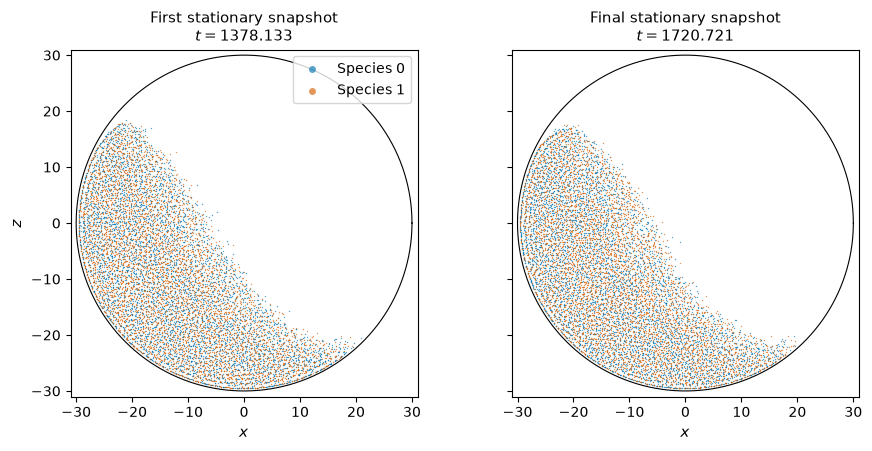

Saved: /Users/rallen/Documents/msc-rom-particle-systems/results/figures/particle_stationary_endpoints_ratio_1_000000_num_1.pdf
Saved: /Users/rallen/Documents/msc-rom-particle-systems/results/figures/particle_stationary_endpoints_ratio_1_000000_num_1.png


In [19]:
import matplotlib.pyplot as plt


FIGURES_DIRECTORY = PROJECT_ROOT / "results" / "figures"
FIGURES_DIRECTORY.mkdir(parents=True, exist_ok=True)

ENDPOINT_FIGURE_PDF = (
    FIGURES_DIRECTORY
    / "particle_stationary_endpoints_ratio_1_000000_num_1.pdf"
)

ENDPOINT_FIGURE_PNG = (
    FIGURES_DIRECTORY
    / "particle_stationary_endpoints_ratio_1_000000_num_1.png"
)

species_colours = {
    0: "#0072B2",
    1: "#D55E00",
}

circle_angle = np.linspace(0, 2 * np.pi, 500)
drum_x = 30 * np.cos(circle_angle)
drum_z = 30 * np.sin(circle_angle)

endpoint_information = [
    (
        positions_xz[0],
        "First stationary snapshot",
        snapshot_times[0],
    ),
    (
        positions_xz[-1],
        "Final stationary snapshot",
        snapshot_times[-1],
    ),
]

with plt.rc_context(
    {
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 11,
    }
):
    figure, axes = plt.subplots(
        1,
        2,
        figsize=(9.0, 4.4),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )

    for axis, (
        endpoint_positions,
        title,
        snapshot_time,
    ) in zip(axes, endpoint_information):
        for species_index in np.unique(reference_species):
            mask = reference_species == species_index

            axis.scatter(
                endpoint_positions[mask, 0],
                endpoint_positions[mask, 1],
                s=1.0,
                alpha=0.65,
                color=species_colours[int(species_index)],
                linewidths=0,
                rasterized=True,
                label=f"Species {int(species_index)}",
            )

        axis.plot(
            drum_x,
            drum_z,
            color="black",
            linewidth=0.8,
        )

        axis.set_title(
            f"{title}\n"
            rf"$t={snapshot_time:.3f}$"
        )
        axis.set_xlabel(r"$x$")
        axis.set_aspect("equal")
        axis.set_xlim(-31, 31)
        axis.set_ylim(-31, 31)
        axis.grid(False)

    axes[0].set_ylabel(r"$z$")
    axes[0].legend(
        loc="upper right",
        markerscale=5,
        frameon=True,
    )

    figure.savefig(
        ENDPOINT_FIGURE_PDF,
        bbox_inches="tight",
    )
    figure.savefig(
        ENDPOINT_FIGURE_PNG,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

print("Saved:", ENDPOINT_FIGURE_PDF)
print("Saved:", ENDPOINT_FIGURE_PNG)

## 8. Conclusions and limitations

### Results established in this notebook

- The pilot DEM file contains 1,002 snapshots with 10,792 particles in every
  snapshot. Its timestamps agree exactly with the associated energy file.
- Applying the Route A stationary threshold, $t \geq 1377$, selects 201
  particle snapshots spanning approximately 1.991 drum revolutions.
- The radius and species sequences remain identical throughout all 201 selected
  snapshots. The final particle positions also agree exactly with the restart
  file. This provides strong evidence that row ordering represents consistent
  labelled particles within this simulation.
- The complete three-dimensional representation has shape
  $201 \times 10{,}792 \times 3$. Its corresponding POD matrix has 32,376
  features and 201 snapshots.
- The $x$–$z$ coordinates retain approximately 99.599% of the centred
  positional fluctuation, while the transverse $y$ coordinate contributes
  approximately 0.401%. The three-dimensional representation will remain the
  primary particle state; the $x$–$z$ representation will be used as a
  physically motivated diagnostic and for comparison with two-dimensional
  coarse-grained fields.
- Individual labelled particles move substantial distances even though the
  macroscopic bed shape remains visually similar. This motivates the hypothesis
  that microscopic particle states will be less low-rank than coarse-grained
  continuum fields. It does not yet establish a POD-rank result.
- The stationary interval provides a natural blocked experiment: the first
  physical revolution contains 101 snapshots and the second contains 100.
  Notebook 11 can learn a basis from the first revolution and evaluate temporal
  repeatability on the second.

### Important limitations

The `.data` rows do not contain explicit particle IDs. The evidence above
supports correspondence within this single trajectory, but does not establish
correspondence between different simulations. Notebook 09 also showed that
particle count changes substantially with size ratio. Therefore, a naive global
fixed-coordinate POD across all parameter values is not currently justified.

The two-cycle split is a temporal validation experiment, not an independent
parameter-generalisation test. Results from the full 201-snapshot POD must also
be labelled as descriptive compression because the same snapshots are used to
construct and assess that basis.

### Next step

Notebook 11 will perform particle-level POD in both XYZ and XZ coordinates. It
will separately report:

1. full-window descriptive singular-value decay and reconstruction;
2. first-cycle basis performance on the blocked second cycle;
3. particle reconstruction errors and physical-validity diagnostics.

No comparison with Route A continuum ranks will be made until matched
instantaneous coarse-grained fields have been constructed from these same DEM
snapshots.